# 01 â€” Exploratory Data Analysis

This notebook explores the **LTMM (Long Term Movement Monitoring)** dataset:
- Clinical/demographic metadata
- Lab-walk accelerometer signals (1-min, 6-channel, 100 Hz)
- Faller vs non-faller class distributions
- Signal visualisation for representative subjects

In [1]:
import sys, pathlib
# Ensure the src directory is importable
ROOT = pathlib.Path.cwd().parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from posturisk.preprocess import (
    load_clinical_data,
    load_lab_walk_features,
    parse_hea,
    read_wfdb_signal,
    DEFAULT_RAW_DIR,
    DEFAULT_PROCESSED_DIR,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
%matplotlib inline

## 1. Clinical / Demographic Data

In [2]:
clinical = load_clinical_data()
print(f'Shape: {clinical.shape}')
print(f'Columns: {list(clinical.columns)}')
clinical.head(10)

Shape: (44, 19)
Columns: ['subject_id', 'gender', 'age', 'year_fall', 'six_month_fall', 'gds', 'abc_pct', 'sf36', 'pase', 'mmse', 'moca', 'fab', 'tmta', 'tmtb', 'tug', 'fsst', 'berg', 'dgi', 'is_faller']


,subject_id,gender,age,year_fall,six_month_fall,gds,abc_pct,sf36,pase,mmse,moca,fab,tmta,tmtb,tug,fsst,berg,dgi,is_faller
0,CO-001,1,75.167693,1.0,0.0,1.0,88.0,82.0,122.65,29.0,23.0,16,102,146,8.00,9.00,52,22,0
1,CO-002,0,82.921287,0.0,0.0,0.0,97.5,90.0,97.72,NaN,26.0,14,84,145,7.58,9.11,54,23,0
2,CO-003,1,75.342916,0.0,0.0,0.0,94.0,74.0,68.60,27.0,24.0,16,55,126,11.00,12.50,53,19,0
3,CO-004,1,69.182752,0.0,0.0,3.0,82.8,56.0,148.05,28.0,16.0,16,103,234,9.56,11.53,51,22,0
4,CO-005,0,77.615332,0.0,0.0,4.0,98.0,68.0,111.08,30.0,27.0,15,65,161,11.82,13.70,54,22,0
5,CO-006,1,77.812457,0.0,0.0,2.0,87.5,87.0,74.35,30.0,27.0,15,60,160,9.37,10.12,56,22,0
6,CO-007,1,76.618754,0.0,0.0,6.0,81.0,61.0,198.37,28.0,25.0,17,99,103,7.81,8.34,56,22,0
7,CO-008,1,82.217659,0.0,0.0,1.0,87.0,75.0,96.07,30.0,26.0,18,40,126,12.11,14.25,47,19,0
8,CO-009,1,79.638604,0.0,0.0,0.0,87.0,86.0,103.05,26.0,25.0,18,40,84,11.50,10.87,56,22,0
9,CO-010,0,81.774127,0.0,0.0,0.0,86.0,90.0,133.44,26.0,20.0,11,76,162,8.83,12.25,55,24,0


In [3]:
# Summary statistics
clinical.describe().round(2)

,gender,age,year_fall,six_month_fall,gds,abc_pct,sf36,pase,mmse,moca,fab,tmta,tmtb,tug,fsst,berg,dgi,is_faller
count,44.00,43.00,43.00,43.00,42.00,43.00,42.00,43.00,43.00,43.00,44.00,44.00,44.00,44.00,44.00,44.00,44.00,44.0
mean,0.64,78.91,0.19,0.14,2.31,83.83,72.19,116.56,28.53,24.51,16.16,74.52,147.07,10.05,11.84,53.27,22.25,0.0
std,0.49,4.60,0.39,0.35,2.33,16.29,17.93,57.31,1.18,2.63,2.21,25.32,52.85,2.49,3.12,2.57,1.75,0.0
min,0.00,66.09,0.00,0.00,0.00,33.00,31.00,14.35,25.00,16.00,11.00,25.00,84.00,6.24,6.52,45.00,17.00,0.0
25%,0.00,76.63,0.00,0.00,0.25,81.90,59.25,70.69,28.00,23.00,15.00,59.75,104.50,7.98,10.16,52.00,21.00,0.0
50%,1.00,78.49,0.00,0.00,1.50,87.81,77.00,111.30,29.00,25.00,16.00,71.50,139.50,10.11,11.48,54.00,22.50,0.0
75%,1.00,81.97,0.00,0.00,4.00,95.75,86.75,152.60,29.00,26.00,17.25,92.75,163.00,11.67,12.95,55.00,24.00,0.0
max,1.00,89.00,1.00,1.00,8.00,100.00,98.00,265.09,30.00,29.00,23.00,130.00,300.00,18.96,23.00,56.00,24.00,0.0


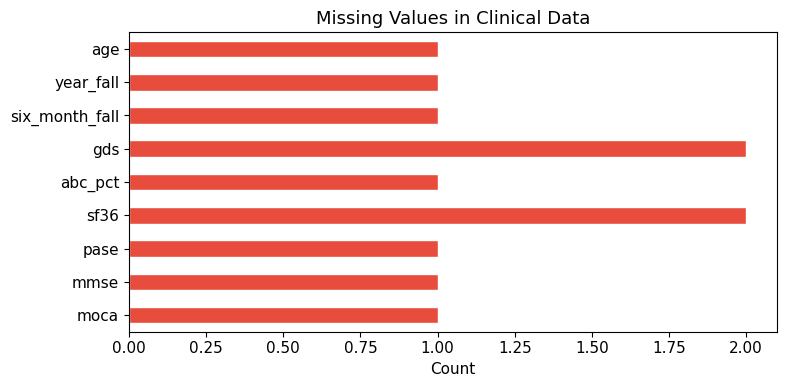

In [4]:
# Missing values
missing = clinical.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing.plot.barh(ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_title('Missing Values in Clinical Data')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values!')

## 2. Class Distribution (Fallers vs Non-Fallers)

The clinical Excel file only contains CO (non-faller) data â€” faller labels come from the file prefix in the signal recordings.

In [5]:
# Load the processed features to get the full dataset with labels
features_path = DEFAULT_PROCESSED_DIR / 'features.csv'
if features_path.exists():
    df = pd.read_csv(features_path)
else:
    # Run preprocessing if needed
    from posturisk.preprocess import run_pipeline
    df = run_pipeline()

print(f'Total subjects: {len(df)}')
print(f'Features: {len(df.columns)}')
print()
print(df['is_faller'].value_counts().rename({0: 'Non-Faller', 1: 'Faller'}))

Total subjects: 73
Features: 129

is_faller
Non-Faller    38
Faller        35
Name: count, dtype: int64


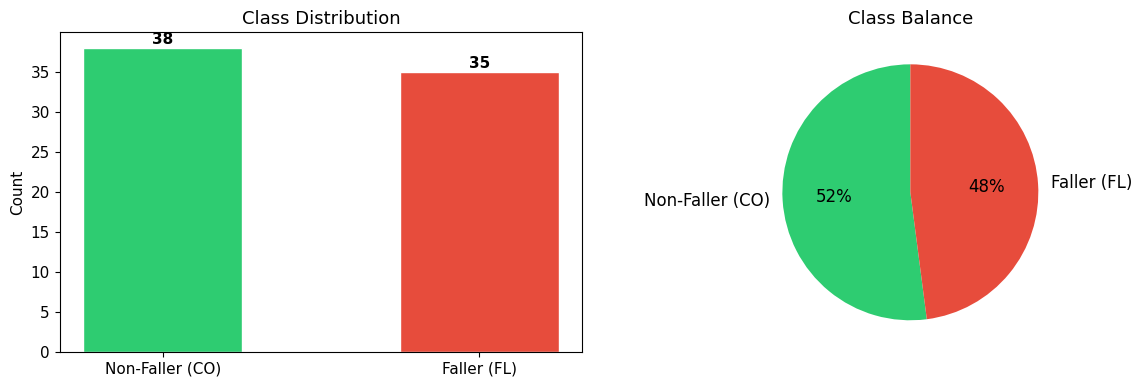

Balance ratio: 0.92 (1.0 = perfectly balanced)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['is_faller'].value_counts().sort_index()
labels = ['Non-Faller (CO)', 'Faller (FL)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.show()

ratio = counts.min() / counts.max()
print(f'Balance ratio: {ratio:.2f} (1.0 = perfectly balanced)')

## 3. Clinical Score Distributions by Faller Status

Note: Clinical scores are only available for CO (non-faller) subjects in this dataset.

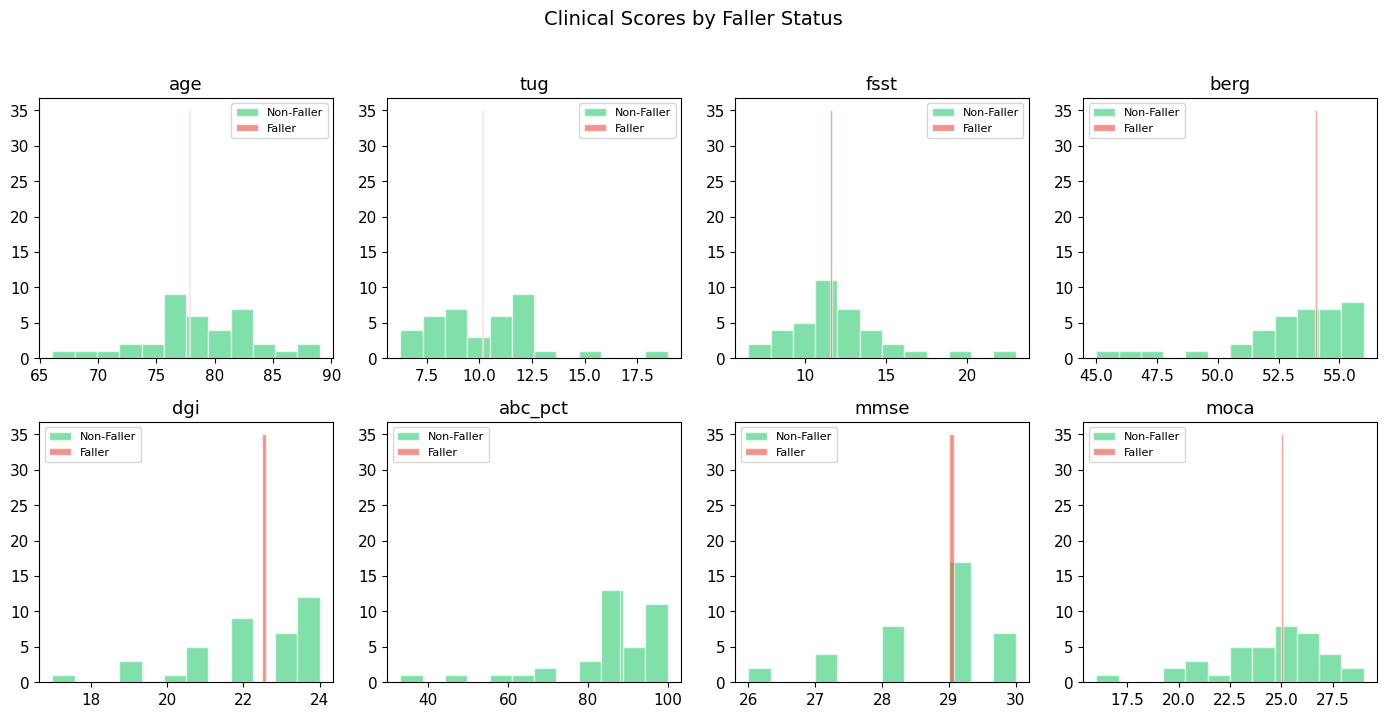

In [7]:
clinical_cols = ['age', 'tug', 'fsst', 'berg', 'dgi', 'abc_pct', 'mmse', 'moca']
available_cols = [c for c in clinical_cols if c in df.columns]

n = len(available_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(available_cols):
    ax = axes[i]
    for label, color, name in [(0, '#2ecc71', 'Non-Faller'), (1, '#e74c3c', 'Faller')]:
        subset = df[df['is_faller'] == label][col].dropna()
        if len(subset) > 0:
            ax.hist(subset, alpha=0.6, color=color, label=name, bins=12, edgecolor='white')
    ax.set_title(col)
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Clinical Scores by Faller Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Raw Accelerometer Signals â€” Example Subjects

Comparing 1-minute lab walk recordings between a non-faller and a faller.

Found 38 non-faller lab walks


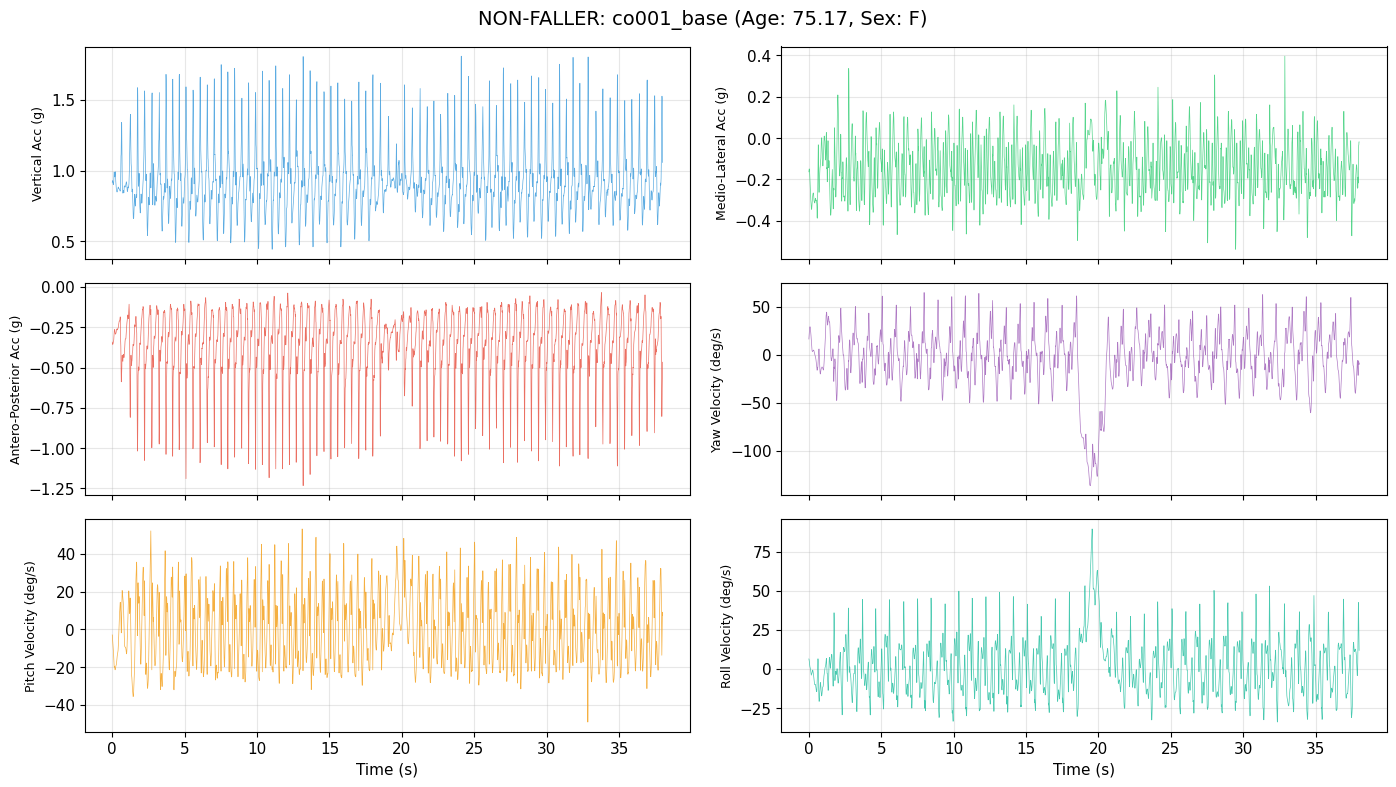

Found 35 faller lab walks


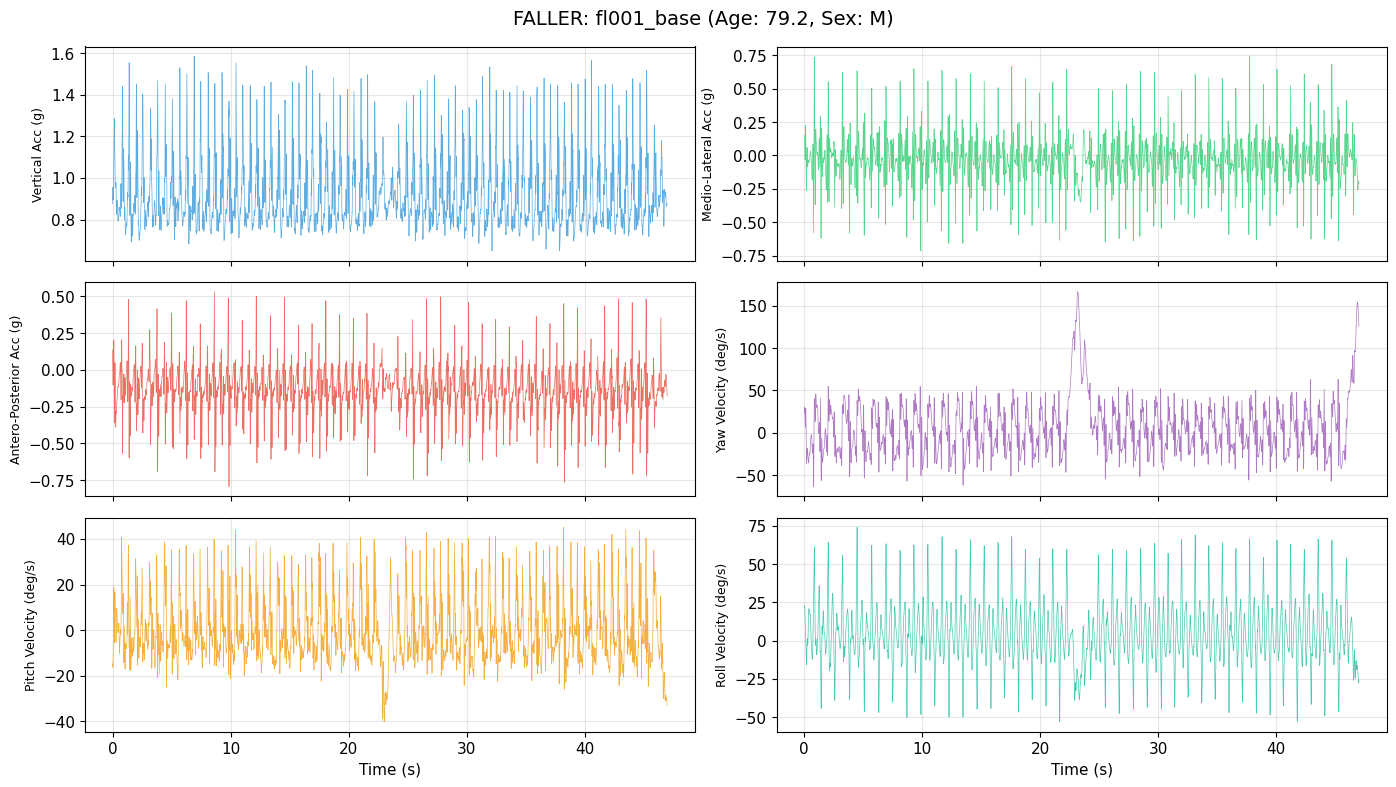

In [8]:
lab_dir = DEFAULT_RAW_DIR / 'LabWalks'

def plot_subject_signals(hea_path, title_prefix=''):
    """Plot all 6 channels for a single subject."""
    header = parse_hea(hea_path)
    signals = read_wfdb_signal(hea_path.with_suffix('.dat'), header)
    t = np.arange(signals.shape[0]) / header.sample_rate
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
    channel_names = ['Vertical Acc (g)', 'Medio-Lateral Acc (g)', 'Antero-Posterior Acc (g)',
                     'Yaw Velocity (deg/s)', 'Pitch Velocity (deg/s)', 'Roll Velocity (deg/s)']
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
    
    for i, (ax, name, color) in enumerate(zip(axes.flatten(), channel_names, colors)):
        ax.plot(t, signals[:, i], color=color, linewidth=0.5, alpha=0.8)
        ax.set_ylabel(name, fontsize=9)
        ax.grid(alpha=0.3)
    
    axes[-1, 0].set_xlabel('Time (s)')
    axes[-1, 1].set_xlabel('Time (s)')
    
    age_str = header.comments.get('age', '?')
    sex_str = header.comments.get('sex', '?')
    fig.suptitle(f'{title_prefix}{header.record_name} (Age: {age_str}, Sex: {sex_str})',
                 fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot a non-faller
co_files = sorted(lab_dir.glob('co*_base.hea'))
fl_files = sorted(lab_dir.glob('fl*_base.hea'))

if co_files:
    print(f'Found {len(co_files)} non-faller lab walks')
    plot_subject_signals(co_files[0], title_prefix='NON-FALLER: ')

if fl_files:
    print(f'Found {len(fl_files)} faller lab walks')
    plot_subject_signals(fl_files[0], title_prefix='FALLER: ')

## 5. Signal Feature Distributions

Comparing key accelerometer features between fallers and non-fallers.

C:\Temp\ipykernel_9284\2675525472.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_faller, faller], labels=['Non-Faller', 'Faller'], patch_artist=True)
C:\Temp\ipykernel_9284\2675525472.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_faller, faller], labels=['Non-Faller', 'Faller'], patch_artist=True)
C:\Temp\ipykernel_9284\2675525472.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_faller, faller], labels=['Non-Faller', 'Faller'], patch_artist=True)
C:\Temp\ipykernel_9284\2675525472.py:19: MatplotlibDeprecationWarning: The 'labels' parameter 

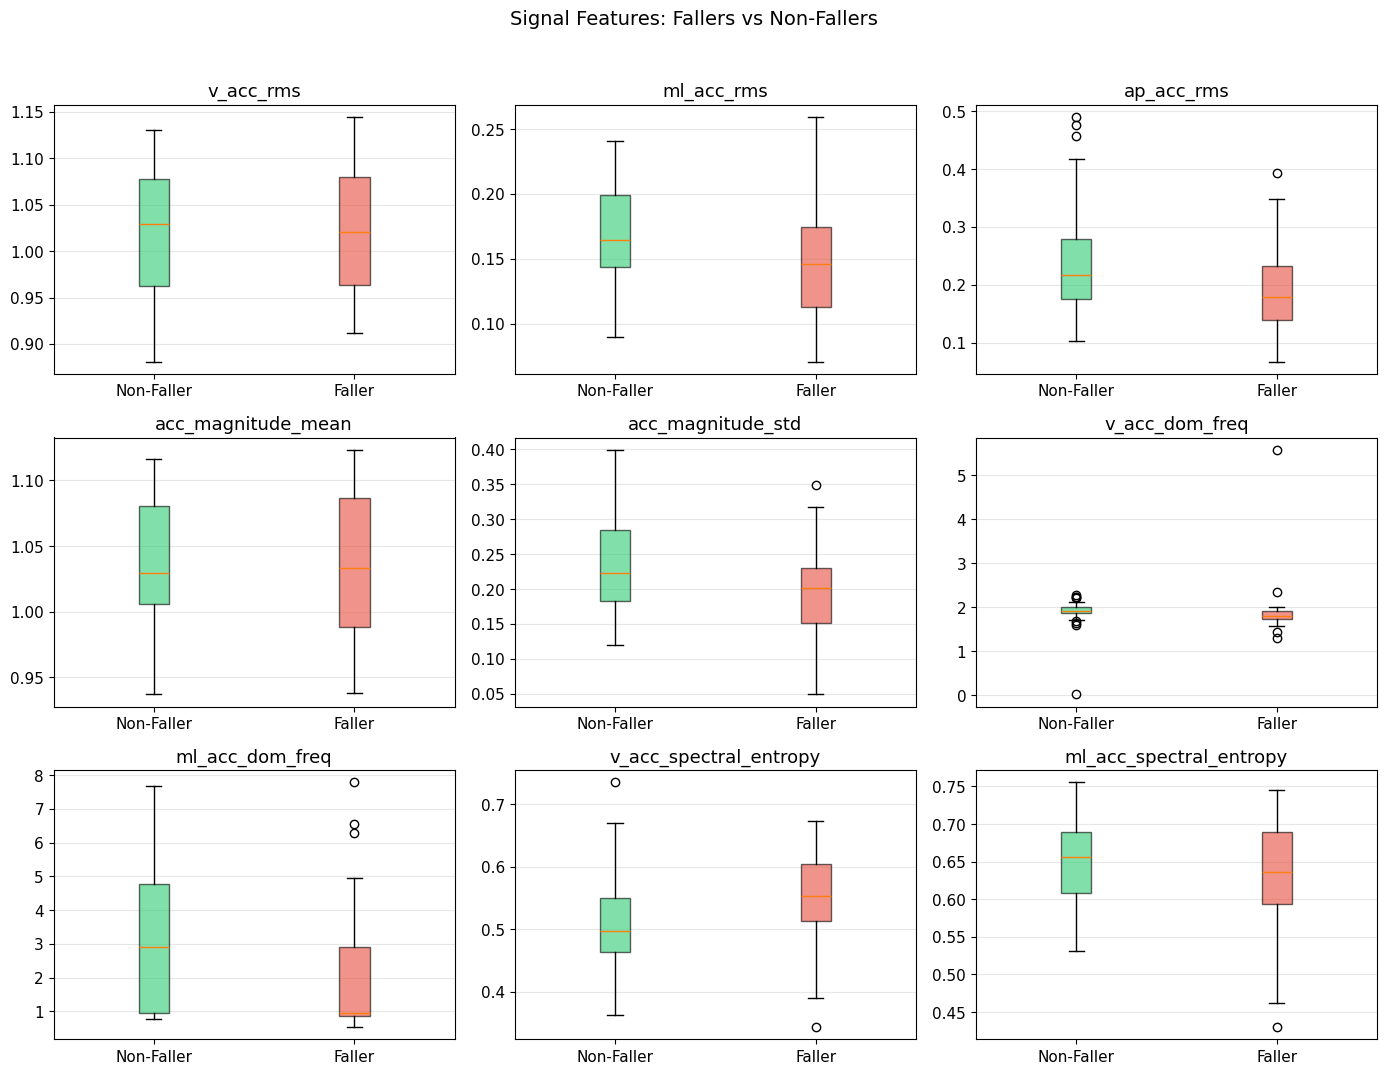

In [9]:
signal_feat_cols = ['v_acc_rms', 'ml_acc_rms', 'ap_acc_rms',
                    'acc_magnitude_mean', 'acc_magnitude_std',
                    'v_acc_dom_freq', 'ml_acc_dom_freq',
                    'v_acc_spectral_entropy', 'ml_acc_spectral_entropy']
available_sig = [c for c in signal_feat_cols if c in df.columns]

n = len(available_sig)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(available_sig):
    ax = axes[i]
    non_faller = df[df['is_faller'] == 0][col].dropna()
    faller = df[df['is_faller'] == 1][col].dropna()
    # Color the boxes individually
    bp = ax.boxplot([non_faller, faller], labels=['Non-Faller', 'Faller'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.6)
    ax.set_title(col)
    ax.grid(alpha=0.3, axis='y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Signal Features: Fallers vs Non-Fallers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 6. Feature Correlation Heatmap

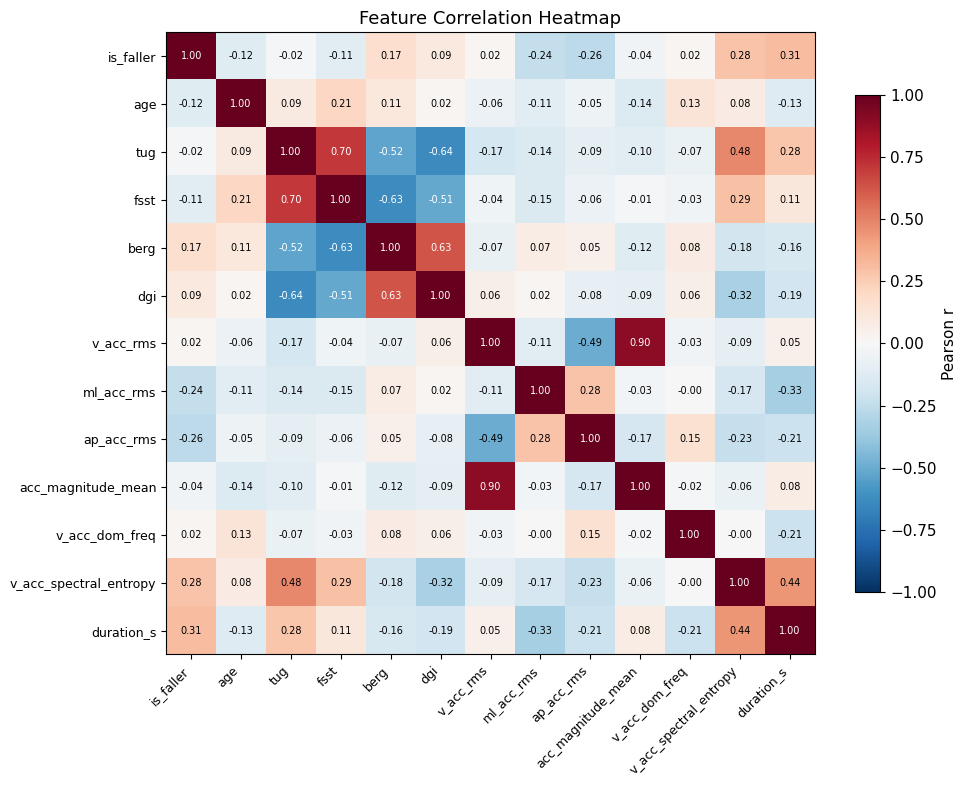

In [10]:
# Select a subset of features for readability
heatmap_cols = ['is_faller', 'age', 'tug', 'fsst', 'berg', 'dgi',
                'v_acc_rms', 'ml_acc_rms', 'ap_acc_rms',
                'acc_magnitude_mean', 'v_acc_dom_freq',
                'v_acc_spectral_entropy', 'duration_s']
heatmap_cols = [c for c in heatmap_cols if c in df.columns]

corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(heatmap_cols)))
ax.set_yticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(heatmap_cols, fontsize=9)

# Annotate cells
for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. Summary

Key findings:
- **73 subjects** total: 38 non-fallers (CO), 35 fallers (FL)
- **Near-balanced** classes (~48% fallers)
- Clinical metadata only available for non-faller group
- **6-channel signals** at 100 Hz: 3 accelerometer + 3 gyroscope
- **89 features** extracted per subject (17 clinical + 69 signal + 3 metadata)
- Signal features (RMS, dominant frequency, spectral entropy) show potential discriminative power